# Drug Response Prediction with Measured Profiles

Measured profiles originate from Mcfarland dataset.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr,ttest_ind
from sklearn.metrics import mean_squared_error
import numpy as np

In [3]:
# Get the project root directory
from pathlib import Path
import sys

project_root = Path.cwd()
sys.path.append(str(project_root.parent))

from notebook_imports import *

In [4]:
# Set project directories using configuration
home_dir = str(config.PROJECT_ROOT)
data_dir = str(config.DATA_DIR)
resources_dir = str(config.RESOURCES_DIR)
results_dir = str(config.RESULTS_04_DIR)
figures_dir = str(config.FIGURES_04_DIR)

In [5]:
# Prediction evaluation function. Either pearsonr or spearmanr
evaluation_function = pearsonr

# Drug to perturbation mapping
mcfarland_drug_to_pert = pd.read_csv(os.path.join(resources_dir, 'mcfarland_drug_to_perturbation.csv'))

In [6]:
# Color palettes
pre_post_lfc_palette = {
    'Grey': '#808080',       # Standard grey
    'Red': '#FF0000',        # Bright red
    'Dark Red': '#8B0000'    # Dark red
}
pre_post_lfc_palette = list(pre_post_lfc_palette.values())
    
sens_res_palette = {
    'Resistant': 'darkgrey',  # plum
    'Sensitive': '#FF0000'   # olive
}

In [7]:
def preprocess_for_plotting(results, predictions):
    results['feature_selection'] = results['feature_selection'].replace({'top100 highest variance': 'top100 HVG', 
                                                                                       'top1000 highest variance': 'top1000 HVG',
                                                                                       'top3000 highest variance': 'top3000 HVG',
                                                                                       'DE genes': 'tissue label'})
    
    results = results.replace({'LFC': 'Ln(fold change)', 'pre_treatment': 'Pre', 'post_treatment': 'Post'})

    results['model'] = np.where(results['feature_selection']=='tissue label', 'tissue label', results['model'])
    results.drop_duplicates(inplace=True)

    predictions['feature_selection'] = predictions['feature_selection'].replace({'top100 highest variance': 'top100 HVG', 
                                        'top1000 highest variance': 'top1000 HVG',
                                        'top3000 highest variance': 'top3000 HVG',
                                        'DE genes': 'tissue label'})
    
    predictions = predictions.replace({'pre-treatment': 'pre_treatment', 'post-treatment': 'post_treatment'})
    predictions = predictions.replace({'LFC': 'Ln(fold change)', 'pre_treatment': 'Pre', 'post_treatment': 'Post'})
    predictions['model'] = pd.Categorical(predictions['model'], categories=['Pre','Post', 'Ln(fold change)'], ordered=True)

    predictions['pred_label'] = np.where(predictions['pred'] > 0.2, 1, 0)
    predictions['true_label'] = np.where(predictions['true'] > 0.2, 1, 0)

    return results, predictions

The model is tested in 4 scenarios:
- Unseen (cell line, drug) combination
- Unseen drug
- Unseen cell line
- Unseen drug & unseen cell line

In [17]:
mcfarland_result = pd.read_csv(os.path.join(results_dir,  'mcfarland_regression_seen_seen.csv'), index_col=0)
mcfarland_predictions = pd.read_csv(os.path.join(results_dir,'mcfarland_regression_predictions_seen_seen.csv'), index_col=0)
mcfarland_result, mcfarland_predictions = preprocess_for_plotting(mcfarland_result, mcfarland_predictions)

In [18]:
mcfarland_predictions['test_condition'] = mcfarland_predictions['test_condition'].str.replace('condition=', '')
mcfarland_predictions['test_condition'] = mcfarland_predictions['test_condition'].str.replace('AND tissue=', '')
mcfarland_predictions['test_condition'] = mcfarland_predictions['test_condition'].str.replace(' ', '_')

In [19]:
unique_test_conditions = mcfarland_predictions['test_condition'].unique()

In [20]:
groupby = ['model', 'feature_selection', 'tissue']

counts = mcfarland_predictions.groupby(groupby).size().reset_index(name='count')

C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_1336\734925046.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = mcfarland_predictions.groupby(groupby).size().reset_index(name='count')


In [21]:
ldo_scores = pd.read_csv(os.path.join(results_dir,  'mcfarland_regression_LDO.csv'), index_col=0)
ldo_predictions = pd.read_csv(os.path.join(results_dir,'mcfarland_regression_LDO_predictions.csv'), index_col=0)

ldo_scores, ldo_predictions = preprocess_for_plotting(ldo_scores, ldo_predictions)
ldo_predictions['test_condition'] = ldo_predictions['test_condition'].str.removeprefix('condition=')

ldo_predictions['test_condition'] = ldo_predictions['condition'].astype(str) + '_' + ldo_predictions['tissue'].astype(str)
ldo_predictions = ldo_predictions[ldo_predictions['test_condition'].isin(unique_test_conditions)]


In [22]:
lto_scores = pd.read_csv(os.path.join(results_dir,  'mcfarland_regression_LTO.csv'), index_col=0)
lto_predictions = pd.read_csv(os.path.join(results_dir,'mcfarland_regression_LTO_predictions.csv'), index_col=0)
lto_predictions['test_condition'] = lto_predictions['test_condition'].str.removeprefix('tissue=')

lto_scores, lto_predictions = preprocess_for_plotting(lto_scores, lto_predictions)

lto_predictions['test_condition'] = lto_predictions['condition'].astype(str) + '_' + lto_predictions['tissue'].astype(str)
lto_predictions = lto_predictions[lto_predictions['test_condition'].isin(unique_test_conditions)]
print(lto_predictions.shape)


(2478, 10)


In [23]:
loo_scores = pd.read_csv(os.path.join(results_dir,  'mcfarland_regression_LOO.csv'), index_col=0).replace({'LFC': 'Ln(fold change)', 'pre-treatment': 'Pre', 'post-treatment': 'Post'})
loo_predictions = pd.read_csv(os.path.join(results_dir,'mcfarland_regression_LOO_predictions.csv'), index_col=0).replace({'LFC': 'Ln(fold change)', 'pre-treatment': 'Pre', 'post-treatment': 'Post'})

loo_scores['test_condition'] = loo_scores['test_condition'].str.replace('tissue=','')
loo_scores['test_condition'] = loo_scores['test_condition'].str.replace('OR condition=','')
loo_scores[['tissue_test', 'condition_test']] = loo_scores['test_condition'].str.split(' ', expand=True)

loo_predictions['test_condition'] = loo_predictions['test_condition'].str.replace('tissue=','')
loo_predictions['test_condition'] = loo_predictions['test_condition'].str.replace('OR condition=','')
loo_predictions[['tissue_test', 'condition_test']] = loo_predictions['test_condition'].str.split(' ', expand=True)

loo_predictions = loo_predictions[(loo_predictions['tissue']==loo_predictions['tissue_test'])& (loo_predictions['condition']==loo_predictions['condition_test'])]


loo_predictions['test_condition'] = loo_predictions['condition'].astype(str) + '_' + loo_predictions['tissue'].astype(str)
loo_predictions = loo_predictions[loo_predictions['test_condition'].isin(unique_test_conditions)]

In [24]:
groupby = ['model', 'feature_selection', 'tissue']

pearson_result = mcfarland_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')

ldo_pearson_result = ldo_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')


lto_pearson_result = lto_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')

loo_pearson_result = loo_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy').fillna(0)

skip_tissue_types = list(set(ldo_predictions['tissue'].unique()).difference(set(lto_predictions['tissue'].unique())))

lto_pearson_result = lto_pearson_result[lto_pearson_result['tissue'].isin(skip_tissue_types)==False].copy()
ldo_pearson_result = ldo_pearson_result[ldo_pearson_result['tissue'].isin(skip_tissue_types)==False].copy()
pearson_result = pearson_result[pearson_result['tissue'].isin(skip_tissue_types)==False].copy()
loo_pearson_result = loo_pearson_result[loo_pearson_result['tissue'].isin(skip_tissue_types)==False].copy()

all_results = pd.concat([pearson_result.assign(test='T1:\nSeen drug, \nseen cell line'), ldo_pearson_result.assign(test='T3:\nUnseen drug,\nseen cell line'), lto_pearson_result.assign(test='T2:\nSeen drug,\nunseen cell line'), loo_pearson_result.assign(test='T4:\nUnseen drug,\nunseen cell line')])

all_results = all_results.rename(columns={'tissue': 'test_instance'})
all_results['accuracy'] = all_results['accuracy'].fillna(0)

C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_1336\4227477299.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pearson_result = mcfarland_predictions.groupby(groupby).apply(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_1336\4227477299.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pearson_result = mcfarland_predictions.groupby(groupby).apply(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_1336\4227477299.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to Tru

In [25]:
groupby = ['model', 'feature_selection', 'condition']

pearson_result = mcfarland_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')

ldo_pearson_result = ldo_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')


lto_pearson_result = lto_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy')

loo_pearson_result = loo_predictions.groupby(groupby).apply(
    lambda group: evaluation_function(group['true'], group['pred'])[0]
).reset_index(name='accuracy').fillna(0)


all_results_condition = pd.concat([pearson_result.assign(test='T1:\nSeen drug, \nseen cell line'), ldo_pearson_result.assign(test='T3:\nUnseen drug,\nseen cell line'), lto_pearson_result.assign(test='T2:\nSeen drug,\nunseen cell line'), loo_pearson_result.assign(test='T4:\nUnseen drug,\nunseen cell line')])

all_results_condition = all_results_condition.rename(columns={'tissue': 'test_instance'})
all_results_condition['accuracy'] = all_results_condition['accuracy'].fillna(0)

C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_1336\3208153904.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pearson_result = mcfarland_predictions.groupby(groupby).apply(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_1336\3208153904.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pearson_result = mcfarland_predictions.groupby(groupby).apply(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_1336\3208153904.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to Tru

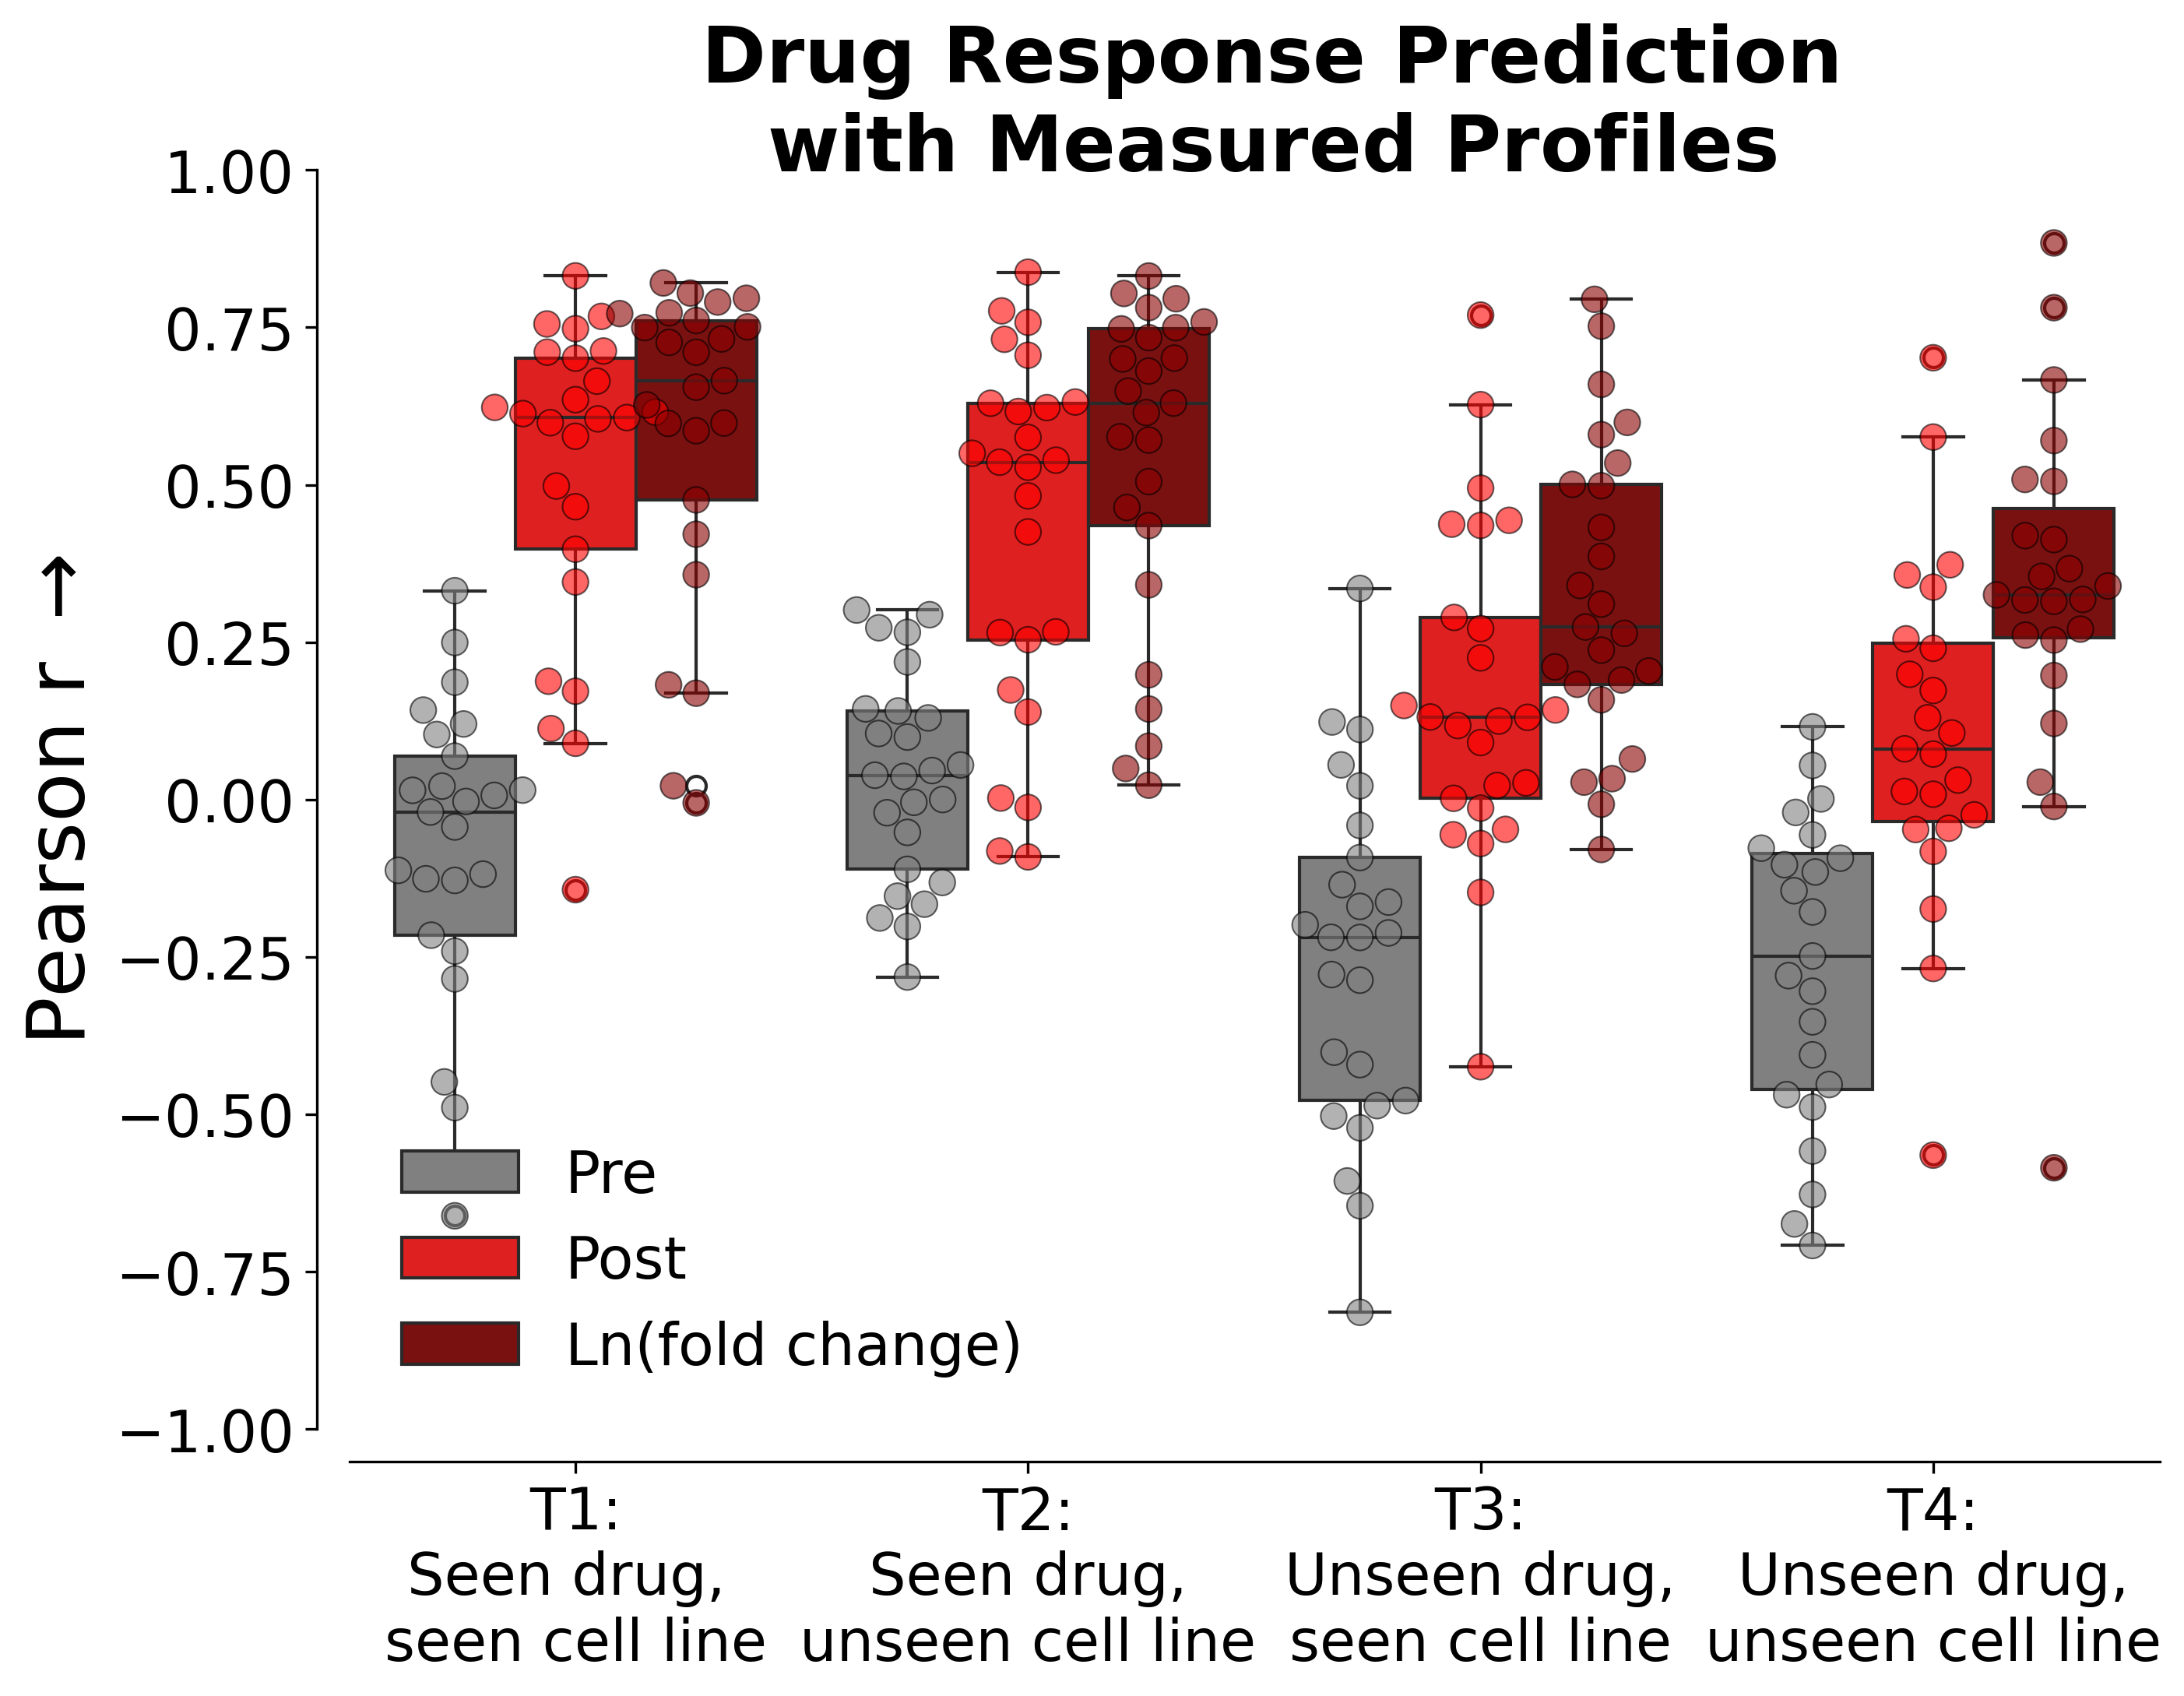

In [27]:
from itertools import combinations
from collections import defaultdict
from statsmodels.stats.multitest import multipletests

def plot_outcomes2(all_results, t, yscale='linear'):
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

    # Define categorical order
    model_order = sorted(all_results['model'].unique(), reverse=True)  # Ensure models are always in the same order
    feature_order = ['T1:\nSeen drug, \nseen cell line','T2:\nSeen drug,\nunseen cell line','T3:\nUnseen drug,\nseen cell line','T4:\nUnseen drug,\nunseen cell line']  # Consistent order for feature selection

    # Convert to categorical with explicit order
    all_results['model'] = pd.Categorical(all_results['model'], categories=model_order, ordered=True)
    all_results['test'] = pd.Categorical(all_results['test'], categories=feature_order, ordered=True)

    # # Sort dataframe to match the categorical order
    all_scores = all_results.sort_values(['model', 'test'])

    # Create a boxplot with consistent order
    g = sns.boxplot(data=all_scores, x='test', y='accuracy', hue='model', palette=[pre_post_lfc_palette[0], pre_post_lfc_palette[1], pre_post_lfc_palette[2]])
    # Swarmplot overlay for individual points
    sns.swarmplot(
        data=all_scores,
        x='test',
        y='accuracy',
        hue='model',
        palette=[pre_post_lfc_palette[0], pre_post_lfc_palette[1], pre_post_lfc_palette[2]],
        # palette=['black', 'black', 'black'],
        dodge=True,
        ax=ax,
        alpha=0.6,
        size=8,
        edgecolor="black",
        linewidth=0.5, legend=False
    )
    sns.despine(offset=10, trim=False)

    plt.xlabel('')
    plt.xticks(fontsize=18)
    g.set_ylabel(r'Pearson r $\rightarrow$', fontsize=25)

    plt.yticks(fontsize=18)
    plt.yscale(yscale)
    plt.ylim(-1,1)

    # Calculate p-values
    p_values = []

    # Loop over each test condition
    for test in all_scores['test'].unique():
        subset = all_scores[all_scores['test'] == test]
        models = subset['model'].unique()

        for model1, model2 in combinations(models, 2):
            auc1 = subset[subset['model'] == model1]['accuracy']
            auc2 = subset[subset['model'] == model2]['accuracy']
            _, p_value = ttest_ind(auc1, auc2)
            p_values.append((test, model1, model2, p_value))

    # Adjust p-values for multiple testing
    p_values_df = pd.DataFrame(p_values, columns=['test', 'model1', 'model2', 'p_value'])
    p_values_df['adjusted_p_value'] = multipletests(p_values_df['p_value'], method='fdr_bh')[1]

    # Add p-values to the plot
    bar_width = 1 / (len(model_order) + 1)
    y_offset = 0.02
    line_height = y_offset / 2
    annotation_levels = defaultdict(float)  # tracks current top for each 'test'

    import matplotlib as mpl
    BR = r'\\' if mpl.rcParams['text.usetex'] else '\n'

    # axes[0].set_title(fr"Trained on $\mathbf{{observed}}${BR}Tested on $\mathbf{{observed}}$", fontsize=18)
    fig.text(0.52, 0.87, 
             fr"Drug Response Prediction{BR}with $\mathbf{{Measured}}$ Profiles", 
             ha='center', va='bottom', fontsize=24, fontweight='bold')

    plt.legend(title='', fontsize=18, frameon=False, loc='lower left')

plot_outcomes2(pd.concat([all_results, all_results_condition]), '')
plt.savefig(os.path.join(figures_dir,'fullmodel_boxplot.pdf'), bbox_inches='tight')
plt.show()

